# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import numpy as np
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [4]:
df = pd.read_csv("MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv", delimiter=',')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [5]:
df.columns

Index(['title', 'Marca', 'Preco_Normal', 'Preco_Desconto', 'Preco_Anterior',
       'Desconto', 'Categoria'],
      dtype='str')

In [6]:
df.dtypes

title               str
Marca               str
Preco_Normal      int64
Preco_Desconto    int64
Preco_Anterior    int64
Desconto          int64
Categoria           str
dtype: object

In [7]:
medianas = df.groupby('Categoria')['Preco_Normal'].agg(mediana='median')
medias = df.groupby('Categoria')['Preco_Normal'].agg(media='mean')


In [8]:
medianas

,mediana
Categoria,
belleza-y-cuidado-personal,1569.0
comidas-preparadas,3290.0
congelados,1519.0
frutas,1195.0
instantaneos-y-sopas,439.0
lacteos,989.0
verduras,1180.0


In [9]:
medias

,media
Categoria,
belleza-y-cuidado-personal,1783.556485
comidas-preparadas,3095.043478
congelados,2108.042553
frutas,1724.473684
instantaneos-y-sopas,765.491228
lacteos,2385.219239
verduras,1343.296875


In [10]:
df = df.merge(medias, on='Categoria')
df = df.merge(medianas, on='Categoria')

def classificar(row):
    if row['media'] < row['mediana']:
        return 'abaixo'
    elif row['media'] > row['mediana']:
        return 'acima'
    else:
        return 'igual'

df['classificacao'] = df.apply(classificar,axis=1)
df['classificacao']

0       acima
1       acima
2       acima
3       acima
4       acima
        ...  
1102    acima
1103    acima
1104    acima
1105    acima
1106    acima
Name: classificacao, Length: 1107, dtype: str

In [11]:
df_filtrado = df[df['classificacao'] == 'acima']
resumo = df_filtrado.groupby('Categoria').size().reset_index(name='quantidade_acima')

resumo

,Categoria,quantidade_acima
0,belleza-y-cuidado-personal,239
1,congelados,235
2,frutas,19
3,instantaneos-y-sopas,57
4,lacteos,447
5,verduras,64


Colocar isso em um grafico para melhor visualizacao

In [12]:
df['Categoria'].unique()

<StringArray>
[                   'lacteos', 'belleza-y-cuidado-personal',
                 'congelados',                     'frutas',
         'comidas-preparadas',                   'verduras',
       'instantaneos-y-sopas']
Length: 7, dtype: str

In [13]:
mapa = {'belleza-y-cuidado-personal' : 'Beleza',
        'lacteos' : 'Lacteos',
        'congelados' : 'Congelados',
        'frutas' : 'Frutas',
        'verduras' : 'Verduras',
       'comidas-preparadas' : 'fast food',
       'instantaneos-y-sopas': 'sopas'}

df['Categoria'] = df['Categoria'].map(mapa)

<Axes: xlabel='Categoria', ylabel='Preco_Normal'>

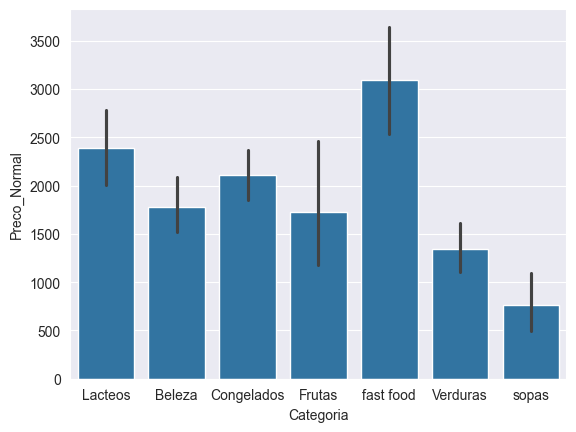

In [16]:
sns.barplot(x="Categoria", y="Preco_Normal", data=df)

Digite aqui as categorias:

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [17]:
desvio = df.groupby('Categoria')['Preco_Normal'].agg(desvio='std', media='mean', mediana='median')
desvio

,desvio,media,mediana
Categoria,,,
Beleza,2210.041719,1783.556485,1569.0
Congelados,2111.539896,2108.042553,1519.0
Frutas,1639.151114,1724.473684,1195.0
Lacteos,3925.816164,2385.219239,989.0
Verduras,1012.699625,1343.296875,1180.0
fast food,2019.911428,3095.043478,3290.0
sopas,1170.232869,765.491228,439.0


A mediana fica consideravelmente longe da media

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

In [18]:
df_lacteos = df.loc[df['Categoria'] == 'Lacteos']
df_lacteos

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria,media,mediana,classificacao
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,Lacteos,2385.219239,989.0,acima
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,Lacteos,2385.219239,989.0,acima
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,Lacteos,2385.219239,989.0,acima
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,Lacteos,2385.219239,989.0,acima
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,Lacteos,2385.219239,989.0,acima
...,...,...,...,...,...,...,...,...,...,...
1017,Leche cultivada probiótico y vitamina D chirim...,Soprole,0,1900,2279,379,Lacteos,2385.219239,989.0,acima
1018,Mantequilla con sal 250 g,Colun,0,1990,2379,389,Lacteos,2385.219239,989.0,acima
1027,Margarina Light Sureña 500 g,Sureña,0,2071,2589,518,Lacteos,2385.219239,989.0,acima
1028,Margarina Sureña 500 g,Sureña,0,2103,2629,526,Lacteos,2385.219239,989.0,acima


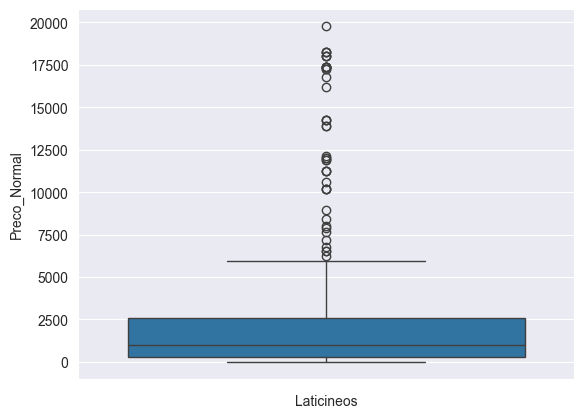

In [19]:
sns.boxplot( y='Preco_Normal', data=df_lacteos)
plt.xlabel('Laticineos')
plt.show()

Uma pequena parte fica entre o intervalo de 0-2500 e tambem entre 2500-5000.Podemos notar a presenca alta de outliers podendo trazer erros a nossa analise.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

<Axes: xlabel='Categoria', ylabel='media'>

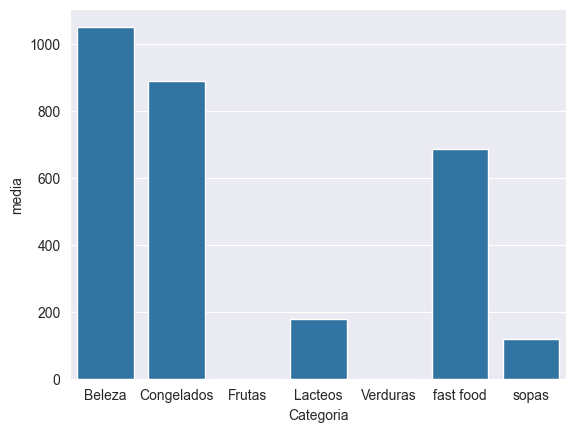

In [22]:
media_desconto = df.groupby('Categoria')['Preco_Desconto'].agg(media='mean').reset_index()
sns.barplot(x='Categoria', y='media' , data=media_desconto)


# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [23]:
media_nova = df.groupby(['Categoria', 'Marca'])['Preco_Desconto'].agg(media='mean').reset_index()

fig = px.density_heatmap(
    media_nova,
    x='Marca',
    y='Categoria',
    z='media',
    title='Mapa de calor'  
)
fig.show()